<a href="https://colab.research.google.com/github/MarcoFRB/ANACAFE_ClusterAFOLU_II/blob/main/PROTOTIPO1_AFOLU_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
##PROTOTIPO DE APLICACIÓN PARA EL MANEJO DE SOMBRA##
##ClústerAFOLU_II##

Mounted at /content/drive

Imágenes disponibles:

1. 20260625_103124.jpg
2. 20260625_103201.jpg
3. 20260625_103223 (1).jpg
4. 20260625_103223.jpg

Seleccione imagen: 2


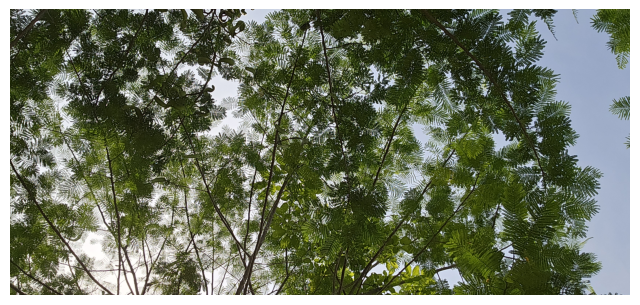


========== RESUMEN ==========
Archivo      : 20260625_103201.jpg
Resolución   : 3392 x 1564
Coordenadas  : (9.005639,-79.587745)
Cámara       : Galaxy S24 Ultra
Fecha        : 2026:06:25 10:32:01
Estado       : VALID



In [3]:
# ==========================================================
# SMARTSHADE COFFEE
# MÓDULO 1 - ADQUISICIÓN DE DATOS
# ANACAFÉ - AFOLU II
# ==========================================================

from google.colab import drive
from PIL import Image, ExifTags
from dataclasses import dataclass
from datetime import datetime
import matplotlib.pyplot as plt
import glob, os, json, numpy as np

# ---------------------- CONFIGURACIÓN ----------------------

drive.mount('/content/drive')

PROJECT_FOLDER = "/content/drive/MyDrive/Cluster_Copernicus_AFOLU"

LATITUDE = 9.005639
LONGITUDE = -79.587745

VALID_FORMATS = (".jpg", ".jpeg", ".png")
MIN_SIZE = 1000

# ---------------------- CLASE ----------------------

@dataclass
class AcquisitionResult:
    filename:str
    filepath:str
    width:int
    height:int
    latitude:float
    longitude:float
    capture_date:str
    camera:str
    status:str
    image:np.ndarray

# ---------------------- FUNCIONES ----------------------

def extract_exif(img):
    camera="No disponible"
    date=datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    try:
        exif=img.getexif()
        if exif:
            exif={ExifTags.TAGS.get(k,k):v for k,v in exif.items()}
            camera=exif.get("Model",camera)
            date=exif.get("DateTime",date)
    except:
        pass
    return camera,date

def load_image():

    images=sorted(glob.glob(os.path.join(PROJECT_FOLDER,"*.jpg")))

    if len(images)==0:
        raise Exception("No se encontraron imágenes.")

    print("\nImágenes disponibles:\n")

    for i,img in enumerate(images):
        print(f"{i+1}. {os.path.basename(img)}")

    idx=int(input("\nSeleccione imagen: "))-1

    path=images[idx]

    img=Image.open(path).convert("RGB")

    if min(img.size)<MIN_SIZE:
        raise Exception("Resolución insuficiente.")

    plt.figure(figsize=(8,8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    camera,date=extract_exif(img)

    return AcquisitionResult(
        filename=os.path.basename(path),
        filepath=path,
        width=img.size[0],
        height=img.size[1],
        latitude=LATITUDE,
        longitude=LONGITUDE,
        capture_date=date,
        camera=camera,
        status="VALID",
        image=np.array(img)
    )

def save_metadata(acq):

    metadata={
        "archivo":acq.filename,
        "latitud":acq.latitude,
        "longitud":acq.longitude,
        "fecha":acq.capture_date,
        "camara":acq.camera,
        "resolucion":[acq.width,acq.height],
        "estado":acq.status
    }

    with open("metadata.json","w") as f:
        json.dump(metadata,f,indent=4)

def main():

    acquisition=load_image()

    save_metadata(acquisition)

    print("\n========== RESUMEN ==========")
    print(f"Archivo      : {acquisition.filename}")
    print(f"Resolución   : {acquisition.width} x {acquisition.height}")
    print(f"Coordenadas  : ({acquisition.latitude},{acquisition.longitude})")
    print(f"Cámara       : {acquisition.camera}")
    print(f"Fecha        : {acquisition.capture_date}")
    print(f"Estado       : {acquisition.status}")
    print("=============================\n")

    return acquisition

# ---------------------- EJECUCIÓN ----------------------

acquisition = main()

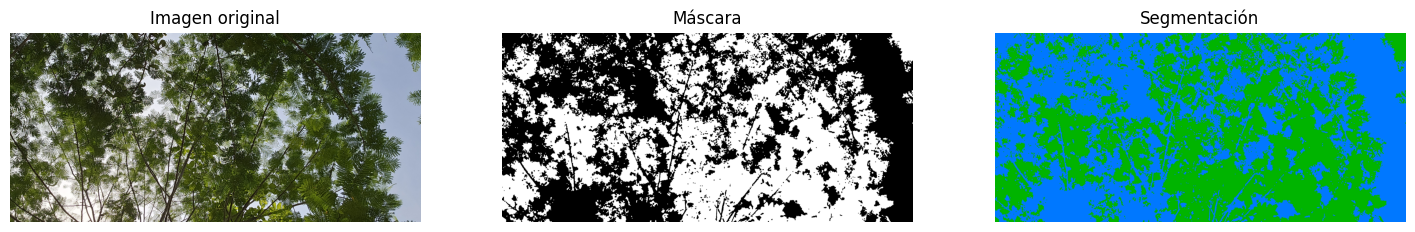

RESULTADOS DEL ANÁLISIS DE SOMBRA
Cobertura vegetal : 48.41 %
Cielo             : 51.59 %
Sombra estimada   : 48.41 %
Confianza MVP     :  85.0 %


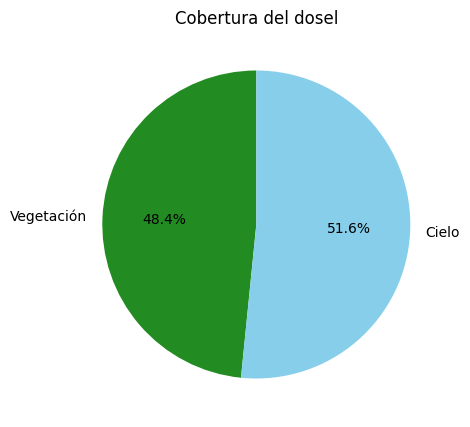

In [4]:
# ==========================================================
# SMARTSHADE COFFEE
# MÓDULO II - ESTIMACIÓN DEL % DE SOMBRA
# MVP basado en Visión por Computadora
# (Preparado para reemplazar por CNN)
# ==========================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

# ----------------------------------------------------------
# Resultado del análisis
# ----------------------------------------------------------

@dataclass
class ShadowMetrics:
    shadow_percent: float
    canopy_percent: float
    sky_percent: float
    confidence: float
    segmented_image: np.ndarray
    mask: np.ndarray

# ----------------------------------------------------------
# Segmentación
# ----------------------------------------------------------

def predict_shadow(image):

    # RGB -> BGR para OpenCV
    bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

    # RGB -> HSV
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)

    # Índice Excess Green (ExG)
    rgb = image.astype(np.float32)

    R = rgb[:,:,0]
    G = rgb[:,:,1]
    B = rgb[:,:,2]

    exg = 2*G - R - B

    exg = cv2.normalize(exg,None,0,255,cv2.NORM_MINMAX).astype(np.uint8)

    # Umbral automático (Otsu)
    _,mask1 = cv2.threshold(
        exg,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Segmentación HSV para vegetación
    lower = np.array([25,40,40])
    upper = np.array([95,255,255])

    mask2 = cv2.inRange(hsv,lower,upper)

    # Combinar ambas máscaras
    mask = cv2.bitwise_or(mask1,mask2)

    # Limpieza morfológica
    kernel = np.ones((5,5),np.uint8)

    mask = cv2.morphologyEx(mask,cv2.MORPH_OPEN,kernel)

    mask = cv2.morphologyEx(mask,cv2.MORPH_CLOSE,kernel)

    # Estadísticos

    vegetation = np.sum(mask==255)

    total = mask.size

    canopy = vegetation/total*100

    sky = 100-canopy

    shadow = canopy

    # Imagen segmentada

    segmented = image.copy()

    segmented[mask==0]=[0,120,255]

    segmented[mask==255]=[0,180,0]

    return ShadowMetrics(
        shadow_percent=shadow,
        canopy_percent=canopy,
        sky_percent=sky,
        confidence=0.85,
        segmented_image=segmented,
        mask=mask
    )

# ----------------------------------------------------------
# Ejecutar
# ----------------------------------------------------------

shadow = predict_shadow(acquisition.image)

# ----------------------------------------------------------
# Resultados
# ----------------------------------------------------------

fig,ax = plt.subplots(1,3,figsize=(18,6))

ax[0].imshow(acquisition.image)
ax[0].set_title("Imagen original")
ax[0].axis("off")

ax[1].imshow(shadow.mask,cmap="gray")
ax[1].set_title("Máscara")
ax[1].axis("off")

ax[2].imshow(shadow.segmented_image)
ax[2].set_title("Segmentación")
ax[2].axis("off")

plt.show()

# ----------------------------------------------------------
# Estadísticos
# ----------------------------------------------------------

print("="*45)
print("RESULTADOS DEL ANÁLISIS DE SOMBRA")
print("="*45)

print(f"Cobertura vegetal : {shadow.canopy_percent:5.2f} %")
print(f"Cielo             : {shadow.sky_percent:5.2f} %")
print(f"Sombra estimada   : {shadow.shadow_percent:5.2f} %")
print(f"Confianza MVP     : {shadow.confidence*100:5.1f} %")

print("="*45)

# ----------------------------------------------------------
# Gráfico
# ----------------------------------------------------------

plt.figure(figsize=(5,5))

plt.pie(
    [shadow.canopy_percent,shadow.sky_percent],
    labels=["Vegetación","Cielo"],
    autopct="%1.1f%%",
    colors=["forestgreen","skyblue"],
    startangle=90
)

plt.title("Cobertura del dosel")

plt.show()

In [5]:
# ==========================================================
# SMARTSHADE COFFEE
# MÓDULO III - CARACTERIZACIÓN DEL RÉGIMEN ACTUAL
# ==========================================================

from dataclasses import dataclass
import pandas as pd

# ----------------------------------------------------------
# Resultado
# ----------------------------------------------------------

@dataclass
class ShadowClassification:

    shadow_percent: float
    category: str
    description: str

# ----------------------------------------------------------
# Clasificación
# ----------------------------------------------------------

def classify_shadow(shadow_percent):

    if shadow_percent < 20:

        category = "Sin sombra"
        description = "Cobertura insuficiente."

    elif shadow_percent < 40:

        category = "Sombra baja"
        description = "Protección limitada del cafetal."

    elif shadow_percent < 60:

        category = "Sombra media"
        description = "Cobertura adecuada."

    else:

        category = "Sombra alta"
        description = "Exceso de cobertura arbórea."

    return ShadowClassification(
        shadow_percent,
        category,
        description
    )

# ----------------------------------------------------------
# Ejecutar
# ----------------------------------------------------------

classification = classify_shadow(shadow.shadow_percent)

# ----------------------------------------------------------
# Resultados
# ----------------------------------------------------------

tabla = pd.DataFrame({

    "Indicador":[
        "% Sombra",
        "Categoría",
        "Interpretación"
    ],

    "Resultado":[
        f"{classification.shadow_percent:.1f} %",
        classification.category,
        classification.description
    ]

})

print("\n========== RÉGIMEN ACTUAL ==========\n")

display(tabla)

print("\n====================================")


========== RÉGIMEN ACTUAL ==========



,Indicador,Resultado
0,% Sombra,48.4 %
1,Categoría,Sombra media
2,Interpretación,Cobertura adecuada.


In [7]:
# ==========================================================
# SMARTSHADE COFFEE
# MÓDULO IV - RÉGIMEN IDEAL DE SOMBRA (MVP)
# ==========================================================

from dataclasses import dataclass
import pandas as pd

#----------------------------------------------------------
# Clase
#----------------------------------------------------------

@dataclass
class OptimalShadow:

    altitude: float
    slope: float
    temperature: float
    rainfall: float

    shadow_percent: float
    category: str

#----------------------------------------------------------
# Motor agronómico (versión MVP)
#----------------------------------------------------------

def estimate_optimal_shadow(lat, lon):

    # --------------------------------------------------
    # En la siguiente versión estos valores vendrán de:
    #
    # Google Earth Engine
    # Copernicus DEM
    # Sentinel-2
    # CHIRPS
    # ERA5
    # --------------------------------------------------

    altitude = 15          # msnm
    slope = 0               # %
    temperature = 27         # °C
    rainfall = 2200          # mm/año

    # Reglas agronómicas simplificadas

    if altitude < 1000:

        shadow = 30
        category = "Sombra baja"

    elif altitude < 1500:

        shadow = 45
        category = "Sombra media"

    else:

        shadow = 60
        category = "Sombra alta"

    return OptimalShadow(
        altitude,
        slope,
        temperature,
        rainfall,
        shadow,
        category
    )

#----------------------------------------------------------
# Ejecutar
#----------------------------------------------------------

optimal = estimate_optimal_shadow(
    acquisition.latitude,
    acquisition.longitude
)

#----------------------------------------------------------
# Mostrar resultados
#----------------------------------------------------------

display(pd.DataFrame({

    "Variable":[
        "Altitud (m)",
        "Pendiente (%)",
        "Temperatura (°C)",
        "Precipitación (mm)",
        "% sombra ideal",
        "Categoría"
    ],

    "Valor":[
        optimal.altitude,
        optimal.slope,
        optimal.temperature,
        optimal.rainfall,
        f"{optimal.shadow_percent:.1f} %",
        optimal.category
    ]

}))

,Variable,Valor
0,Altitud (m),15
1,Pendiente (%),0
2,Temperatura (°C),27
3,Precipitación (mm),2200
4,% sombra ideal,30.0 %
5,Categoría,Sombra baja


In [8]:
# ==========================================================
# SMARTSHADE COFFEE
# MÓDULO V - ANÁLISIS DE BRECHA
# ==========================================================

from dataclasses import dataclass
import pandas as pd

#----------------------------------------------------------
# Clase
#----------------------------------------------------------

@dataclass
class GapAnalysis:

    current_shadow: float
    optimal_shadow: float
    difference: float
    status: str
    traffic_light: str

#----------------------------------------------------------
# Comparación
#----------------------------------------------------------

def gap_analysis(current, optimal):

    diff = round(current.shadow_percent - optimal.shadow_percent, 1)

    if abs(diff) <= 5:

        status = "Sombra adecuada"
        traffic = "🟢"

    elif diff < -5:

        status = "Sombra deficiente"
        traffic = "🟡"

    else:

        status = "Sombra excesiva"
        traffic = "🔴"

    return GapAnalysis(
        current.shadow_percent,
        optimal.shadow_percent,
        diff,
        status,
        traffic
    )

#----------------------------------------------------------
# Ejecutar
#----------------------------------------------------------

gap = gap_analysis(shadow, optimal)

#----------------------------------------------------------
# Mostrar resultados
#----------------------------------------------------------

display(pd.DataFrame({

    "Indicador":[
        "Sombra actual (%)",
        "Sombra ideal (%)",
        "Diferencia (%)",
        "Clasificación",
        "Semáforo"
    ],

    "Resultado":[
        f"{gap.current_shadow:.1f}",
        f"{gap.optimal_shadow:.1f}",
        f"{gap.difference:+.1f}",
        gap.status,
        gap.traffic_light
    ]

}))

print("\n===================================")
print("ANÁLISIS DE BRECHA COMPLETADO")
print("===================================")

,Indicador,Resultado
0,Sombra actual (%),48.4
1,Sombra ideal (%),30.0
2,Diferencia (%),+18.4
3,Clasificación,Sombra excesiva
4,Semáforo,🔴



ANÁLISIS DE BRECHA COMPLETADO


In [9]:
# ==========================================================
# SMARTSHADE COFFEE
# MÓDULO VI - SISTEMA EXPERTO (RENTABILIDAD SUSTENTABLE)
# ==========================================================

from dataclasses import dataclass
import pandas as pd

#----------------------------------------------------------
# Clase
#----------------------------------------------------------

@dataclass
class Recommendation:

    status: str
    priority: str
    actions: list

#----------------------------------------------------------
# Sistema experto basado en reglas
#----------------------------------------------------------

def generate_recommendations(gap):

    if gap.status == "Sombra adecuada":

        priority = "BAJA"

        actions = [
            "Mantener la densidad actual de árboles de sombra.",
            "Realizar podas sanitarias periódicas.",
            "Monitorear el crecimiento del dosel cada 6 meses.",
            "Conservar especies de sombra compatibles con café.",
            "Continuar el manejo agronómico según Rentabilidad Sustentable."
        ]

    elif gap.status == "Sombra deficiente":

        priority = "ALTA"

        actions = [
            "Incrementar gradualmente la cobertura arbórea.",
            "Establecer especies de sombra recomendadas por ANACAFÉ.",
            "Evitar la exposición excesiva al sol durante la época seca.",
            "Proteger árboles jóvenes hasta lograr la cobertura objetivo.",
            "Reevaluar el porcentaje de sombra después de la siguiente temporada lluviosa."
        ]

    else:

        priority = "MEDIA"

        actions = [
            "Realizar podas selectivas para aumentar la entrada de luz.",
            "Eliminar ramas improductivas o excesivamente densas.",
            "Favorecer la ventilación del cafetal.",
            "Reducir humedad excesiva para disminuir riesgo de enfermedades.",
            "Monitorear nuevamente la cobertura después de las podas."
        ]

    return Recommendation(
        gap.status,
        priority,
        actions
    )

#----------------------------------------------------------
# Ejecutar
#----------------------------------------------------------

recommendation = generate_recommendations(gap)

#----------------------------------------------------------
# Mostrar resultados
#----------------------------------------------------------

print("\n================ RECOMENDACIONES RS ================\n")

print(f"Diagnóstico : {recommendation.status}")
print(f"Prioridad   : {recommendation.priority}\n")

for i,action in enumerate(recommendation.actions,1):

    print(f"{i}. {action}")

display(pd.DataFrame({

    "Prioridad":[recommendation.priority],
    "Diagnóstico":[recommendation.status],
    "Acciones recomendadas":[len(recommendation.actions)]

}))

print("\n====================================================")


================ RECOMENDACIONES RS ================

Diagnóstico : Sombra excesiva
Prioridad   : MEDIA

1. Realizar podas selectivas para aumentar la entrada de luz.
2. Eliminar ramas improductivas o excesivamente densas.
3. Favorecer la ventilación del cafetal.
4. Reducir humedad excesiva para disminuir riesgo de enfermedades.
5. Monitorear nuevamente la cobertura después de las podas.


,Prioridad,Diagnóstico,Acciones recomendadas
0,MEDIA,Sombra excesiva,5
